In [ ]:
!pip -q install --force-reinstall --no-deps scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.2 MB/s eta 0:00:00


In [ ]:
!pip -q install geotessera rioxarray leafmap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.9/258.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 

In [ ]:
# ============================================================
# Block 13A: Imports and study areas
# ============================================================
import numpy as np                     # embeddings are arrays of numbers
import pandas as pd                    # tables
import geopandas as gpd                # tables with geometry
import matplotlib.pyplot as plt        # plots

from geotessera import GeoTessera      # TESSERA embedding downloader
import rioxarray                       # rasters with coordinates
import leafmap.foliumap as leafmap     # maps in Colab

from sklearn.decomposition import PCA                 # squeeze 128 numbers into 3 colours
from sklearn.ensemble import RandomForestClassifier   # simple crop classifier
from sklearn.metrics import accuracy_score, classification_report

# --- Study areas: Netherlands ---
train_point    = [5.65, 52.55]  #  Flevoland: reclaimed polder farmland near Dronten/Swifterbant (lon, lat)
transfer_point = [6.75, 53.35]  # North Groningen: clay farmland, same climate and crops
year = 2025     # TESSERA full coverage year;

import sklearn
print("Ready | numpy", np.__version__, "| sklearn", sklearn.__version__)

Ready | numpy 2.1.3 | sklearn 1.9.1


Shape (rows, cols, features): (1137, 719, 128)
Projection: EPSG:32631
One pixel's embedding (first 10 of 128 numbers): [ 2.59  2.59  0.27  4.57  1.64  3.34 -6.   -1.43  1.16  2.32]


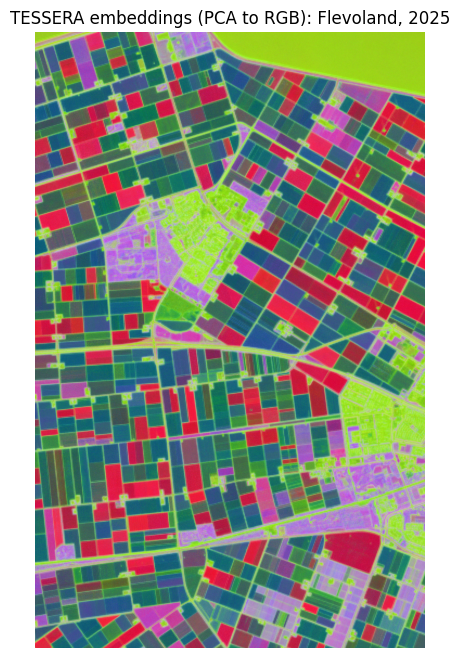

In [ ]:
# ============================================================
# Block 14: Fetch TESSERA embeddings and look at them
# ============================================================
# TESSERA stores the world in tiles of 0.1 x 0.1 degrees (~9 x 11 km here).
# We ask for the tile that contains our point; it returns:
#   emb       : array (rows, cols, 128), with 128 numbers for each 10 m pixel
#   crs       : the map projection (UTM, in metres)
#   transform : how pixel positions map to real-world coordinates
# Default dataset = TESSERA v1, full coverage for 2024.

gt = GeoTessera()

emb, crs, transform = gt.fetch_embedding(lon=train_point[0], lat=train_point[1], year=year)

print("Shape (rows, cols, features):", emb.shape)
print("Projection:", crs)
print("One pixel's embedding (first 10 of 128 numbers):", np.round(emb[500, 500, :10], 2))

# --- PCA: squeeze 128 numbers per pixel into 3, and show them as Red/Green/Blue ---
# Pixels with similar embeddings get similar colours, so fields with the
# same crop should look alike, without any labels.
rows, cols, n_feat = emb.shape
X = emb.reshape(-1, n_feat)                     # one row per pixel

pca = PCA(n_components=3).fit(X[::50])          # fit on every 50th pixel (fast)
rgb = pca.transform(X).reshape(rows, cols, 3)
rgb = (rgb - rgb.min((0, 1))) / (rgb.max((0, 1)) - rgb.min((0, 1)))   # scale to 0-1 for display

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("TESSERA embeddings (PCA to RGB): Flevoland, 2025")
plt.axis("off")
plt.show()

Parcels: 4104 | years: [2025]
gewas
Sloot                                         1409
Agrarisch natuurmengsel                        304
Groene braak, spontane opkomst                 278
Engels raaigras, groenbemesting, vanggewas     248
Grasland, tijdelijk                            230
Tarwe, winter-                                 174
Aardappelen, consumptie                        141
Grasland, blijvend                             139
Name: count, dtype: int64
       class  pct
Not farmland 27.8
   Grassland  5.3
       Maize  1.5
    Potatoes 15.1
  Sugar beet  6.6
       Wheat 14.2
      Onions  9.4
 Other crops 20.0


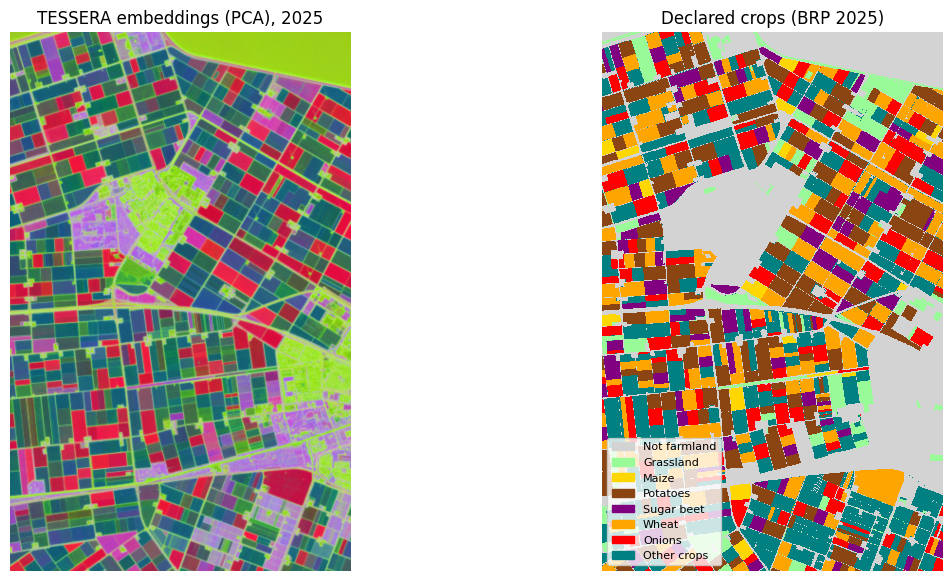

In [ ]:
# ============================================================
# Block 15: Load Dutch crop parcels (BRP) and line them up with the embeddings
# ============================================================
# BRP = Basisregistratie Gewaspercelen: every Dutch farmer draws their fields and
# declares the crop each year (reference date 15 May). The government publishes it
# openly through PDOK. It is VECTOR data: one polygon per field with a crop name.
# The embeddings are a RASTER (10 m pixels), so we "rasterize": burn each field's
# crop class into the pixels it covers, making pixel [i, j] mean the same spot in both.

import requests
from rasterio.features import rasterize
from rasterio.warp import transform_bounds
from matplotlib.colors import ListedColormap

# --- 1. Our tile's box in lon/lat (the API wants degrees) ---
left, top = transform * (0, 0)
right, bottom = transform * (cols, rows)
lonlat_box = transform_bounds(crs, "EPSG:4326", left, bottom, right, top)

# --- 2. Download parcels; the API gives 1,000 per page, so we follow the "next" links ---
url = "https://api.pdok.nl/rvo/gewaspercelen/ogc/v1/collections/brpgewas/items"
params = {"bbox": ",".join(str(v) for v in lonlat_box), "limit": 1000, "f": "json"}
features = []
while url:
    page = requests.get(url, params=params, timeout=60).json()
    features += page["features"]
    url = next((l["href"] for l in page["links"] if l["rel"] == "next"), None)
    params = None                       # the "next" link already contains the parameters
parcels = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
print("Parcels:", len(parcels), "| years:", parcels["jaar"].unique())
print(parcels["gewas"].value_counts().head(8))   # raw Dutch crop names

# --- 3. Translate Dutch crop names into 6 simple groups ---
# Key words: gras = grass, mais = maize, aardappel = potato, biet = beet,
#            tarwe = wheat, ui = onion
def crop_group(name):
    n = name.lower()
    # Not real crops: ditches, nature strips, fallow -> treat as "Not farmland"
    if any(w in n for w in ["sloot", "natuur", "braak"]):   return 0
    # Cover / catch crops (sown between main crops) -> "Other", not grassland
    if "groenbemesting" in n or "vanggewas" in n:            return 7
    if "gras" in n:                 return 1   # Grassland
    if "mais" in n or "maïs" in n:  return 2   # Maize
    if "aardappel" in n:            return 3   # Potatoes
    if "biet" in n:                 return 4   # Sugar beet
    if "tarwe" in n:                return 5   # Wheat
    if "ui" in n.split(",")[0]:     return 6   # Onions ("Uien, ...")
    return 7                                   # Other crops (tulips, vegetables ...)

class_names = {0: "Not farmland", 1: "Grassland", 2: "Maize", 3: "Potatoes",
               4: "Sugar beet", 5: "Wheat", 6: "Onions", 7: "Other crops"}
parcels["class_id"] = parcels["gewas"].apply(crop_group)

# --- 4. Rasterize: burn class_id into the embedding grid (0 = no parcel) ---
parcels_utm = parcels.to_crs(crs)                       # same projection as the embeddings
labels = rasterize(zip(parcels_utm.geometry, parcels_utm["class_id"]),
                   out_shape=(rows, cols), transform=transform, fill=0, dtype="uint8")

codes, counts = np.unique(labels, return_counts=True)
print(pd.DataFrame({"class": [class_names[c] for c in codes],
                    "pct": (100 * counts / counts.sum()).round(1)}).to_string(index=False))

# --- 5. Side by side: embeddings (no labels) vs declared crops ---
crop_cmap = ListedColormap(["lightgrey", "palegreen", "gold", "saddlebrown",
                            "purple", "orange", "red", "teal"])
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(rgb); ax[0].set_title(f"TESSERA embeddings (PCA), {year}")
ax[1].imshow(labels, cmap=crop_cmap, vmin=0, vmax=7, interpolation="nearest")
ax[1].set_title(f"Declared crops (BRP {year})")
handles = [plt.Rectangle((0, 0), 1, 1, color=crop_cmap(i)) for i in range(8)]
ax[1].legend(handles, class_names.values(), loc="lower left", fontsize=8)
for a in ax: a.axis("off")
plt.show()

         main class  % of cluster
row_0                            
0             Wheat          81.0
1          Potatoes          71.0
2      Not farmland          74.0
3            Onions          33.0
4      Not farmland          77.0
5      Not farmland         100.0
6         Grassland          67.0
7             Wheat          67.0

Clusters=8, sample=50000, PCA=None -> purity 64%


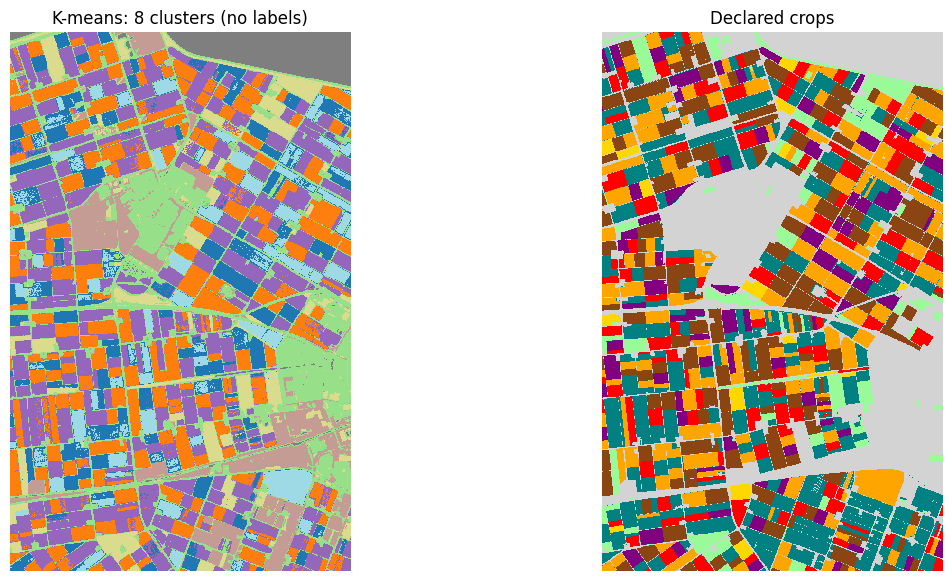

In [ ]:
# ============================================================
# Block 16: K-means clustering — can the embeddings find crops WITHOUT labels?
# ============================================================
# K-means groups pixels into K groups of "look-alikes" using only the 128 numbers.
# It never sees crop names. Afterwards we check each group against the declared
# crops: if a cluster is mostly one crop, the embeddings have "discovered" that crop.

# ===== TRY IT: change these, rerun, compare =====
N_CLUSTERS    = 8       # how many groups: try 4, 8, 12, 20
SAMPLE_PIXELS = 50000   # pixels used to learn the groups: try 5000, 50000, 200000
PCA_DIMS      = None    # None = all 128 numbers; try 3, 10, 30 (fewer = simpler)
# =================================================

from sklearn.cluster import MiniBatchKMeans

X_in = X if PCA_DIMS is None else PCA(n_components=PCA_DIMS).fit(X[::50]).transform(X)
rng = np.random.default_rng(0)
sample = rng.choice(len(X_in), SAMPLE_PIXELS, replace=False)
km = MiniBatchKMeans(n_clusters=N_CLUSTERS, n_init=3, random_state=0).fit(X_in[sample])
clusters = km.predict(X_in).reshape(rows, cols)

# --- Which crop dominates each cluster? ---
counts_ct = pd.crosstab(clusters.ravel(), labels.ravel())
counts_ct.columns = [class_names[c] for c in counts_ct.columns]
pct_ct = counts_ct.div(counts_ct.sum(axis=1), axis=0) * 100
print(pd.DataFrame({"main class": pct_ct.idxmax(axis=1),
                    "% of cluster": pct_ct.max(axis=1).round(0)}))

# Purity: if every cluster were named after its main class, how often would we be right?
purity = counts_ct.max(axis=1).sum() / counts_ct.values.sum()
print(f"\nClusters={N_CLUSTERS}, sample={SAMPLE_PIXELS}, PCA={PCA_DIMS} -> purity {purity:.0%}")

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(clusters, cmap="tab20", interpolation="nearest"); ax[0].set_title(f"K-means: {N_CLUSTERS} clusters (no labels)")
ax[1].imshow(labels, cmap=crop_cmap, vmin=0, vmax=7, interpolation="nearest"); ax[1].set_title("Declared crops")
for a in ax: a.axis("off")
plt.show()

# QUESTIONS for participants:
#  1. Which crop gets a cluster almost to itself? Which crops get mixed together?
#  2. Purity rises as you add clusters. Why is that partly "cheating"?
#  3. With PCA_DIMS = 3 (what you saw as colours in Block 14), how much is lost?

              precision    recall  f1-score   support

   Grassland       0.89      0.92      0.91      2493
    Potatoes       0.97      0.94      0.95      5563
  Sugar beet       0.87      0.95      0.91      2362
       Wheat       0.98      0.96      0.97      5849
      Onions       0.91      0.91      0.91      3733

    accuracy                           0.94     20000
   macro avg       0.93      0.94      0.93     20000
weighted avg       0.94      0.94      0.94     20000

        model  pixels/class  classes   split  accuracy
random_forest           500        5 spatial     0.939


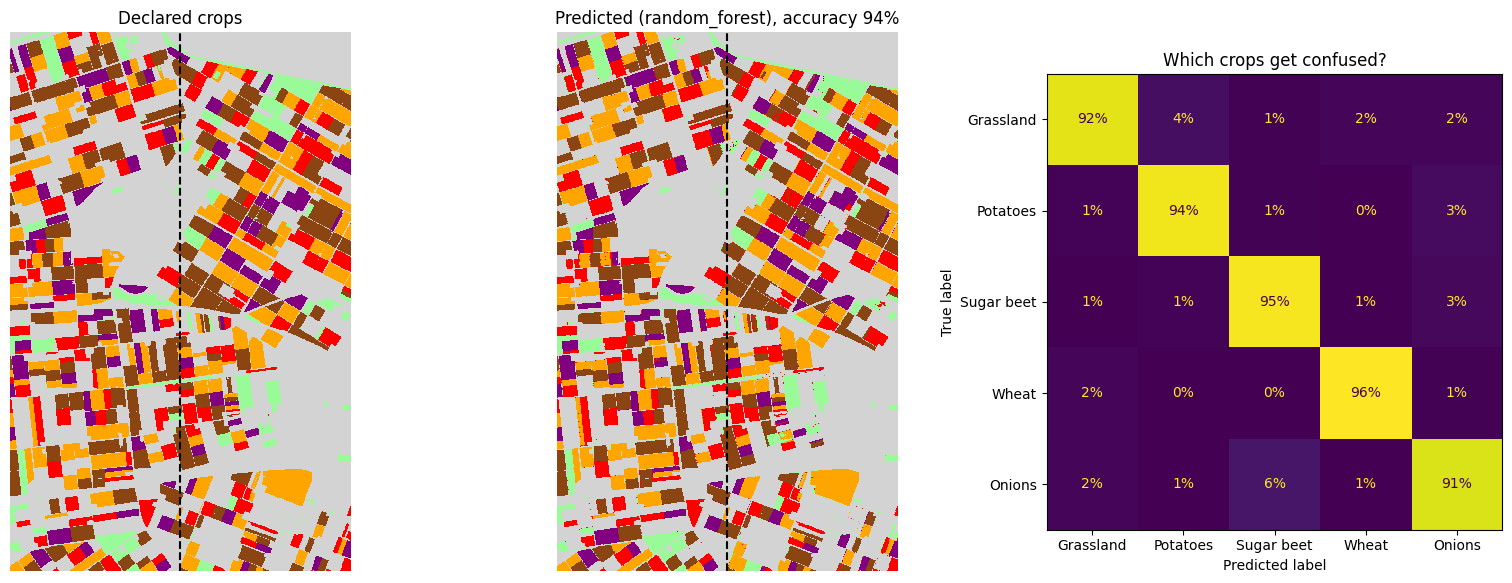

In [ ]:
# ============================================================
# Block 17: Supervised crop classifier — now WITH labels
# ============================================================
# We show the model some pixels with their crop names, it learns the pattern in the
# 128 numbers, then predicts pixels it has never seen. The embeddings did the hard
# deep learning already; we only train a small "head" on top.

# ===== TRY IT: change these, rerun, compare =====
MODEL            = "random_forest"  # "random_forest", "neural_net", "logistic", "knn"
PIXELS_PER_CLASS = 10              # training examples per crop: try 10, 50, 500, 2000
CLASSES          = [1, 3, 4, 5, 6]  # 1 Grass 3 Potato 4 Beet 5 Wheat 6 Onion; try adding 2, 7, 0
SPLIT            = "spatial"        # "spatial" = train on left half, test on right half
                                    # "random"  = pixels mixed at random (see question 3)
# =================================================

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

y_all = labels.ravel()
in_classes = np.isin(y_all, CLASSES)
col_idx = np.tile(np.arange(cols), rows)          # column number of every pixel
rng = np.random.default_rng(0)

if SPLIT == "spatial":
    train_zone, test_zone = col_idx < cols // 2, col_idx >= cols // 2
else:
    coin = rng.random(len(y_all)) < 0.5
    train_zone, test_zone = coin, ~coin

# Balanced training sample: the same number of pixels per crop
def pick(c, n):
    pool = np.where(train_zone & (y_all == c))[0]
    return rng.choice(pool, min(n, len(pool)), replace=False)
train_idx = np.concatenate([pick(c, PIXELS_PER_CLASS) for c in CLASSES])
test_pool = np.where(test_zone & in_classes)[0]
test_idx = rng.choice(test_pool, min(20000, len(test_pool)), replace=False)

models = {
    "random_forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0),
    "neural_net":    make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=0)),
    "logistic":      make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "knn":           KNeighborsClassifier(n_neighbors=5),
}
model = models[MODEL].fit(X[train_idx], y_all[train_idx])

y_pred = model.predict(X[test_idx])
acc = accuracy_score(y_all[test_idx], y_pred)
names = [class_names[c] for c in CLASSES]
print(classification_report(y_all[test_idx], y_pred, labels=CLASSES, target_names=names, zero_division=0))

# --- Keep a running scoreboard across reruns ---
results = globals().get("results", [])
results.append({"model": MODEL, "pixels/class": PIXELS_PER_CLASS, "classes": len(CLASSES),
                "split": SPLIT, "accuracy": round(acc, 3)})
print(pd.DataFrame(results).to_string(index=False))

# --- Maps: declared vs predicted (only pixels of the chosen classes) ---
pred_map = np.zeros(rows * cols, dtype=np.uint8)
pred_map[in_classes] = model.predict(X[in_classes])
true_map = np.where(in_classes, y_all, 0)
fig, ax = plt.subplots(1, 3, figsize=(20, 7))
ax[0].imshow(true_map.reshape(rows, cols), cmap=crop_cmap, vmin=0, vmax=7, interpolation="nearest"); ax[0].set_title("Declared crops")
ax[1].imshow(pred_map.reshape(rows, cols), cmap=crop_cmap, vmin=0, vmax=7, interpolation="nearest"); ax[1].set_title(f"Predicted ({MODEL}), accuracy {acc:.0%}")
if SPLIT == "spatial":
    for a in ax[:2]: a.axvline(cols // 2, color="black", ls="--")   # left = train, right = test
ConfusionMatrixDisplay.from_predictions(y_all[test_idx], y_pred, labels=CLASSES, display_labels=names,
                                        normalize="true", values_format=".0%", ax=ax[2], colorbar=False)
ax[2].set_title("Which crops get confused?")
for a in ax[:2]: a.axis("off")
plt.show()

# QUESTIONS for participants:
#  1. How few pixels per crop still give good accuracy? (try 10)  -> why foundation models matter
#  2. Neural net vs random forest: is the fancier model actually better here?
#  3. Switch SPLIT to "random": accuracy goes UP. Why is that misleading?
#     (Hint: neighbouring pixels in the same field are near-copies.)
#  4. Add Maize (2) or Other crops (7): which crops get confused, and why?

ANOTHER OPTION OF 16-18

Query: Sugar beet pixel at row 890, col 406 | threshold 0.9
Twins found: 59,425 pixels | they cover 76% of all Sugar beet pixels
What the twins really are (% of twins):
Sugar beet      69.1
Potatoes        16.5
Other crops      9.9
Onions           3.2
Not farmland     0.8
Grassland        0.3
Wheat            0.2
Maize            0.0


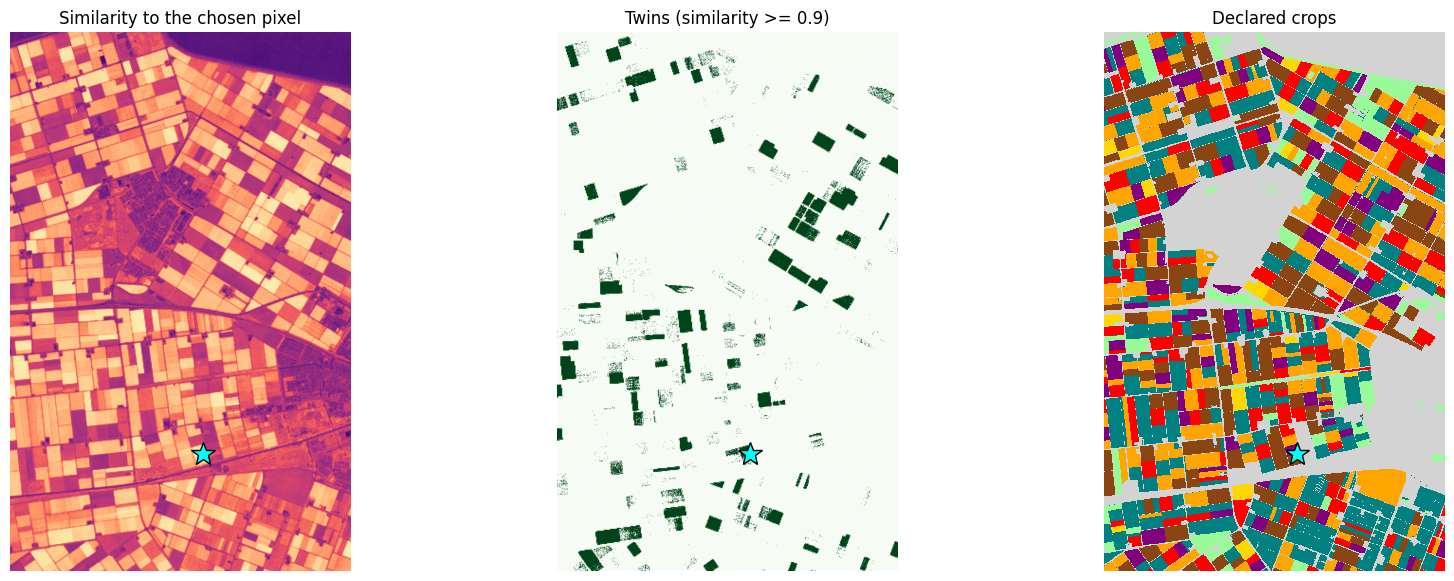

In [ ]:
# ============================================================
# Block 16: "Click a field, find its twins" (similarity search, NO training)
# ============================================================
# Every pixel has 128 numbers. Two pixels are "twins" if their numbers point the
# same way, measured by COSINE SIMILARITY (1 = identical, 0 = unrelated).
# We pick one pixel of a crop and light up every pixel that looks like it.
# No labels and no model training: just comparing embeddings.

# ===== TRY IT: change these, rerun, compare =====
QUERY_CROP = 4      # crop to pick a field from: 1 Grass, 3 Potato, 4 Beet, 5 Wheat, 6 Onion
QUERY_SEED = 2      # change (1, 2, 3 ...) to pick a different field of that crop
THRESHOLD  = 0.90   # how similar counts as a "twin": try 0.6, 0.8, 0.9
# =================================================

# --- 1. Pick one pixel of the chosen crop ---
rng = np.random.default_rng(QUERY_SEED)
candidates = np.argwhere(labels == QUERY_CROP)
r0, c0 = candidates[rng.integers(len(candidates))]

# --- 2. Cosine similarity of every pixel to that one ---
Xn = X / np.linalg.norm(X, axis=1, keepdims=True)       # scale every vector to length 1
sim = (Xn @ Xn[r0 * cols + c0]).reshape(rows, cols)     # one similarity value per pixel
twins = sim >= THRESHOLD

# --- 3. What did we find? Compare twins with the declared crops ---
found = pd.Series(labels[twins]).map(class_names).value_counts(normalize=True).mul(100).round(1)
recall = (twins & (labels == QUERY_CROP)).sum() / (labels == QUERY_CROP).sum()
print(f"Query: {class_names[QUERY_CROP]} pixel at row {r0}, col {c0} | threshold {THRESHOLD}")
print(f"Twins found: {twins.sum():,} pixels | they cover {recall:.0%} of all {class_names[QUERY_CROP]} pixels")
print("What the twins really are (% of twins):")
print(found.to_string())

# --- 4. Maps ---
fig, ax = plt.subplots(1, 3, figsize=(20, 7))
ax[0].imshow(sim, cmap="magma", vmin=0, vmax=1); ax[0].set_title("Similarity to the chosen pixel")
ax[1].imshow(twins, cmap="Greens");              ax[1].set_title(f"Twins (similarity >= {THRESHOLD})")
ax[2].imshow(labels, cmap=crop_cmap, vmin=0, vmax=7, interpolation="nearest"); ax[2].set_title("Declared crops")
for a in ax:
    a.plot(c0, r0, marker="*", color="cyan", markersize=18, markeredgecolor="black")
    a.axis("off")
plt.show()

# QUESTIONS for participants:
#  1. Which crop finds its twins most cleanly? Which gets mixed up with another?
#  2. Raise the threshold to 0.9: fewer twins, but are they more "pure"?
#  3. Try two different potato fields (QUERY_SEED). Do they find the same twins?
#     (Different planting dates or varieties can make "same crop" look different.)

              precision    recall  f1-score   support

   Grassland       0.81      0.92      0.86      2458
    Potatoes       0.97      0.92      0.94      5508
  Sugar beet       0.84      0.93      0.88      2318
       Wheat       0.98      0.96      0.97      5922
      Onions       0.91      0.87      0.89      3794

    accuracy                           0.92     20000
   macro avg       0.90      0.92      0.91     20000
weighted avg       0.93      0.92      0.92     20000

        model  pixels/class  classes   split  accuracy
random_forest           500        5 spatial     0.939
random_forest            10        5 spatial     0.907
random_forest           100        5 spatial     0.923


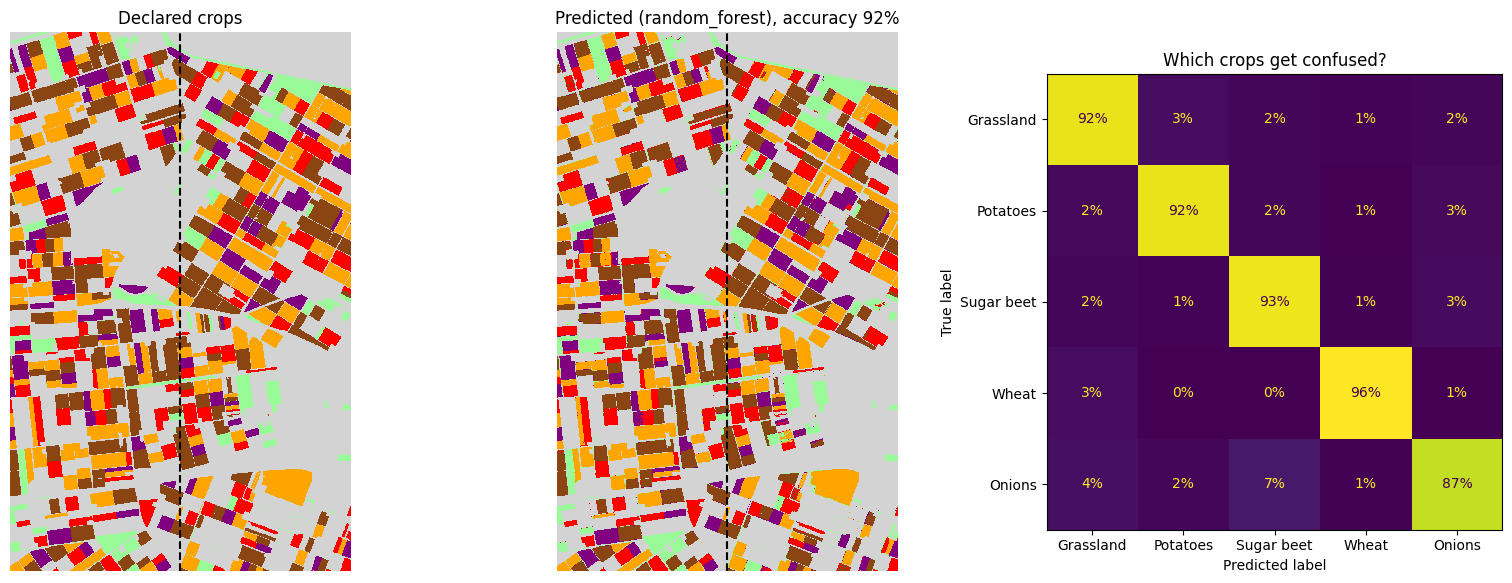

In [ ]:
# ============================================================
# Block 17: Supervised crop classifier — now WITH labels
# ============================================================
# We show the model some pixels with their crop names, it learns the pattern in the
# 128 numbers, then predicts pixels it has never seen. The embeddings did the hard
# deep learning already; we only train a small "head" on top.

# ===== TRY IT: change these, rerun, compare =====
MODEL            = "random_forest"  # "random_forest", "neural_net", "logistic", "knn"
PIXELS_PER_CLASS = 100              # training examples per crop: try 2, 5, 10, 100, 1000
CLASSES          = [1, 3, 4, 5, 6]  # 1 Grass 3 Potato 4 Beet 5 Wheat 6 Onion; try adding 2, 7, 0
SPLIT            = "spatial"        # "spatial" = train on left half, test on right half
                                    # "random"  = pixels mixed at random (see question 3)
# =================================================

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

y_all = labels.ravel()
in_classes = np.isin(y_all, CLASSES)
col_idx = np.tile(np.arange(cols), rows)          # column number of every pixel
rng = np.random.default_rng(0)

if SPLIT == "spatial":
    train_zone, test_zone = col_idx < cols // 2, col_idx >= cols // 2
else:
    coin = rng.random(len(y_all)) < 0.5
    train_zone, test_zone = coin, ~coin

# Balanced training sample: the same number of pixels per crop
def pick(c, n):
    pool = np.where(train_zone & (y_all == c))[0]
    return rng.choice(pool, min(n, len(pool)), replace=False)
train_idx = np.concatenate([pick(c, PIXELS_PER_CLASS) for c in CLASSES])
test_pool = np.where(test_zone & in_classes)[0]
test_idx = rng.choice(test_pool, min(20000, len(test_pool)), replace=False)

models = {
    "random_forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0),
    "neural_net":    make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=0)),
    "logistic":      make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "knn":           KNeighborsClassifier(n_neighbors=5),
}
model = models[MODEL].fit(X[train_idx], y_all[train_idx])

y_pred = model.predict(X[test_idx])
acc = accuracy_score(y_all[test_idx], y_pred)
names = [class_names[c] for c in CLASSES]
print(classification_report(y_all[test_idx], y_pred, labels=CLASSES, target_names=names, zero_division=0))

# --- Keep a running scoreboard across reruns ---
results = globals().get("results", [])
results.append({"model": MODEL, "pixels/class": PIXELS_PER_CLASS, "classes": len(CLASSES),
                "split": SPLIT, "accuracy": round(acc, 3)})
print(pd.DataFrame(results).to_string(index=False))

# --- Maps: declared vs predicted (only pixels of the chosen classes) ---
pred_map = np.zeros(rows * cols, dtype=np.uint8)
pred_map[in_classes] = model.predict(X[in_classes])
true_map = np.where(in_classes, y_all, 0)
fig, ax = plt.subplots(1, 3, figsize=(20, 7))
ax[0].imshow(true_map.reshape(rows, cols), cmap=crop_cmap, vmin=0, vmax=7, interpolation="nearest"); ax[0].set_title("Declared crops")
ax[1].imshow(pred_map.reshape(rows, cols), cmap=crop_cmap, vmin=0, vmax=7, interpolation="nearest"); ax[1].set_title(f"Predicted ({MODEL}), accuracy {acc:.0%}")
if SPLIT == "spatial":
    for a in ax[:2]: a.axvline(cols // 2, color="black", ls="--")   # left = train, right = test
ConfusionMatrixDisplay.from_predictions(y_all[test_idx], y_pred, labels=CLASSES, display_labels=names,
                                        normalize="true", values_format=".0%", ax=ax[2], colorbar=False)
ax[2].set_title("Which crops get confused?")
for a in ax[:2]: a.axis("off")
plt.show()

# QUESTIONS for participants:
#  1. How few pixels per crop still give good accuracy? (try 10)  -> why foundation models matter
#  2. Neural net vs random forest: is the fancier model actually better here?
#  3. Switch SPLIT to "random": accuracy goes UP. Why is that misleading?
#     (Hint: neighbouring pixels in the same field are near-copies.)
#  4. Add Maize (2) or Other crops (7): which crops get confused, and why?

In [ ]:
# ============================================================
# Block 18: "What changed since last year?" (2024 vs 2025, NO labels needed)
# ============================================================
# TESSERA gives one embedding per pixel per YEAR. If a field grew the same thing
# both years, its two embeddings point the same way. If the crop changed,
# they point in different directions.
# change = 1 - cosine similarity  (0 = no change, larger = more change)
# The same idea later spots floods, fires or hail damage: compare before vs after.

from ipywidgets import interact, FloatSlider, Dropdown

# --- 1. Last year's embeddings for the SAME tile (same model version, so comparable) ---
emb_prev, _, _ = gt.fetch_embedding(lon=train_point[0], lat=train_point[1], year=year - 1)
X_prev = emb_prev.reshape(-1, n_feat)

# --- 2. Change score for every pixel ---
Xpn = X_prev / np.linalg.norm(X_prev, axis=1, keepdims=True)
change = np.nan_to_num(1 - (Xn * Xpn).sum(axis=1)).reshape(rows, cols)
print("Typical change score (median):", round(float(np.median(change)), 2))

# --- 3. PCA colours for both years on the SAME colour scale (fitted in Block 14) ---
P_now, P_prev = pca.transform(X), pca.transform(X_prev)
lo, hi = P_now.min(0), P_now.max(0)
rgb_now  = np.clip((P_now  - lo) / (hi - lo), 0, 1).reshape(rows, cols, 3)
rgb_prev = np.clip((P_prev - lo) / (hi - lo), 0, 1).reshape(rows, cols, 3)

# --- 4. Interactive view ---
crop_options = {"All crops": None, **{class_names[c]: c for c in range(1, 8)}}

def show_change(threshold, crop):
    changed = change >= threshold
    sel = labels > 0 if crop_options[crop] is None else labels == crop_options[crop]
    pct = [100 * (changed & (labels == c)).sum() / max((labels == c).sum(), 1) for c in range(1, 8)]
    fig, ax = plt.subplots(1, 4, figsize=(24, 6))
    ax[0].imshow(rgb_prev); ax[0].set_title(f"{year - 1} embeddings")
    ax[1].imshow(rgb_now);  ax[1].set_title(f"{year} embeddings")
    ax[2].imshow(np.where(changed & sel, 1.0, np.where(sel, 0.25, 0)), cmap="Reds", vmin=0, vmax=1)
    ax[2].set_title(f"Changed (dark red): {crop}")
    ax[3].barh([class_names[c] for c in range(1, 8)], pct, color=[crop_cmap(c) for c in range(1, 8)])
    ax[3].set_xlim(0, 100); ax[3].set_xlabel("% of pixels changed")
    ax[3].set_title(f"Crop in {year}: how much changed since {year - 1}?")
    for a in ax[:3]: a.axis("off")
    plt.tight_layout(); plt.show()

interact(show_change,
         threshold=FloatSlider(value=0.3, min=0.05, max=1.0, step=0.05,
                               description="Change ≥", continuous_update=False),
         crop=Dropdown(options=list(crop_options), value="All crops", description="Crop 2025"))

# QUESTIONS for participants:
#  1. Which crop changes least? (Grassland stays grass; potato, beet and wheat fields rotate.)
#  2. Most arable fields "changed". Is that damage? No, it's crop rotation.
#     Lesson: before calling something a flood or a loss, know the NORMAL change.
#  3. Move the slider: where would you set the threshold, and why?

Typical change score (median): 0.22


interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='Change ≥', max=1.0, min=0.0…

<function __main__.show_change(threshold, crop)>

In [ ]:
# ============================================================
# Block 19A: Helper: embeddings + Dutch crop labels for any Dutch tile
# (same steps as Block 15, wrapped in one function; run once)
# ============================================================
def fetch_dutch_tile(point, yr=year):
    e, c, tr = gt.fetch_embedding(lon=point[0], lat=point[1], year=yr)
    nr, nc = e.shape[:2]
    l, t = tr * (0, 0); r, b = tr * (nc, nr)
    box = transform_bounds(c, "EPSG:4326", l, b, r, t)
    url = "https://api.pdok.nl/rvo/gewaspercelen/ogc/v1/collections/brpgewas/items"
    params, feats = {"bbox": ",".join(str(v) for v in box), "limit": 1000, "f": "json"}, []
    while url:
        page = requests.get(url, params=params, timeout=60).json()
        feats += page["features"]
        url = next((k["href"] for k in page["links"] if k["rel"] == "next"), None)
        params = None
    g = gpd.GeoDataFrame.from_features(feats, crs="EPSG:4326").to_crs(c)
    g["class_id"] = g["gewas"].apply(crop_group)
    lab = rasterize(zip(g.geometry, g["class_id"]), out_shape=(nr, nc), transform=tr, fill=0, dtype="uint8")
    return e.reshape(-1, e.shape[2]), lab

print("Helper ready")

Helper ready


In [ ]:
# ============================================================
# Block 19B: Transfer learning: pre vs post scoring in a NEW area (Groningen)
# ============================================================
# PRE : model trained only in Flevoland, used as-is in Groningen
# POST: same model + a few LOCAL labels from Groningen
# Fair test: local labels come from the LEFT half of Groningen,
#            accuracy is measured only on the RIGHT half.
from ipywidgets import interact, SelectionSlider

CLASSES_T = [1, 3, 4, 5, 6]                     # Grassland, Potatoes, Sugar beet, Wheat, Onions
rng = np.random.default_rng(0)

# --- 1. Home training data: Flevoland, 300 pixels per crop ---
y_home = labels.ravel()
idx_home = np.concatenate([rng.choice(np.where(y_home == c)[0], 300, replace=False) for c in CLASSES_T])

# --- 2. New area: Groningen ---
X_new, lab_new = fetch_dutch_tile(transfer_point)
nr, nc = lab_new.shape
y_new = lab_new.ravel()
farm = np.isin(y_new, CLASSES_T)
left = np.tile(np.arange(nc), nr) < nc // 2     # left half: where we "collect" local labels
test = farm & ~left                             # right half: where we score

# --- 3. Train with 0, 5, 20, 100 local labels per crop and score each ---
results = {}
for n_local in [0, 5, 20, 100]:
    idx_loc = np.concatenate([rng.choice(np.where(left & (y_new == c))[0],
                                         min(n_local, (left & (y_new == c)).sum()), replace=False)
                              for c in CLASSES_T]).astype(int)
    X_train = np.vstack([X[idx_home], X_new[idx_loc]])
    y_train = np.concatenate([y_home[idx_home], y_new[idx_loc]])
    weight = np.r_[np.ones(len(idx_home)), np.full(len(idx_loc), 10)]   # local examples count 10x
    mdl = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0).fit(X_train, y_train, sample_weight=weight)
    pred = np.zeros(nr * nc, np.uint8); pred[farm] = mdl.predict(X_new[farm])
    results[n_local] = (pred.reshape(nr, nc), accuracy_score(y_new[test], pred[test]))
    print(f"Local labels per crop: {n_local:>3} -> accuracy in Groningen: {results[n_local][1]:.0%}")

# --- 4. Interactive: slide from PRE (0) to POST (100) ---
def show_transfer(local_labels):
    pred, acc = results[local_labels]
    fig, ax = plt.subplots(1, 3, figsize=(21, 7))
    ax[0].imshow(np.where(farm, y_new, 0).reshape(nr, nc), cmap=crop_cmap, vmin=0, vmax=7, interpolation="nearest")
    ax[0].set_title("Groningen: declared crops (truth)")
    ax[1].imshow(pred, cmap=crop_cmap, vmin=0, vmax=7, interpolation="nearest")
    ax[1].set_title(f"{'PRE' if local_labels == 0 else 'POST'}: {local_labels} local labels/crop, accuracy {acc:.0%}")
    for a in ax[:2]:
        a.axvline(nc // 2, color="black", ls="--"); a.axis("off")   # left = local labels, right = scored
    ns = list(results)
    ax[2].bar([str(n) for n in ns], [results[n][1] * 100 for n in ns],
              color=["tomato" if n == local_labels else "lightgrey" for n in ns])
    ax[2].set_ylim(0, 100); ax[2].set_xlabel("local labels per crop"); ax[2].set_ylabel("accuracy %")
    ax[2].set_title("Pre vs post scoring")
    plt.tight_layout(); plt.show()

interact(show_transfer, local_labels=SelectionSlider(options=list(results), value=0, description="Local labels"))

# QUESTIONS for participants:
#  1. How much does accuracy jump from 0 to just 5 local labels per crop?
#  2. Which crop improves most? Look at the maps side by side.
#  3. In a new country, which is cheaper: 100 labels from scratch, or 5 local + a foundation model?

Local labels per crop:   0 -> accuracy in Groningen: 93%
Local labels per crop:   5 -> accuracy in Groningen: 95%
Local labels per crop:  20 -> accuracy in Groningen: 95%
Local labels per crop: 100 -> accuracy in Groningen: 96%


interactive(children=(SelectionSlider(description='Local labels', options=(0, 5, 20, 100), value=0), Output())…

<function __main__.show_transfer(local_labels)>